### Factory Design Pattern

- Build a Notification System that can send messages via different communication channels:
    - Email
    - SMS
    - Push Notification
- Implement the Factory Pattern to create different notification types dynamically.
- Expose an API where users can send a message through their preferred channel.

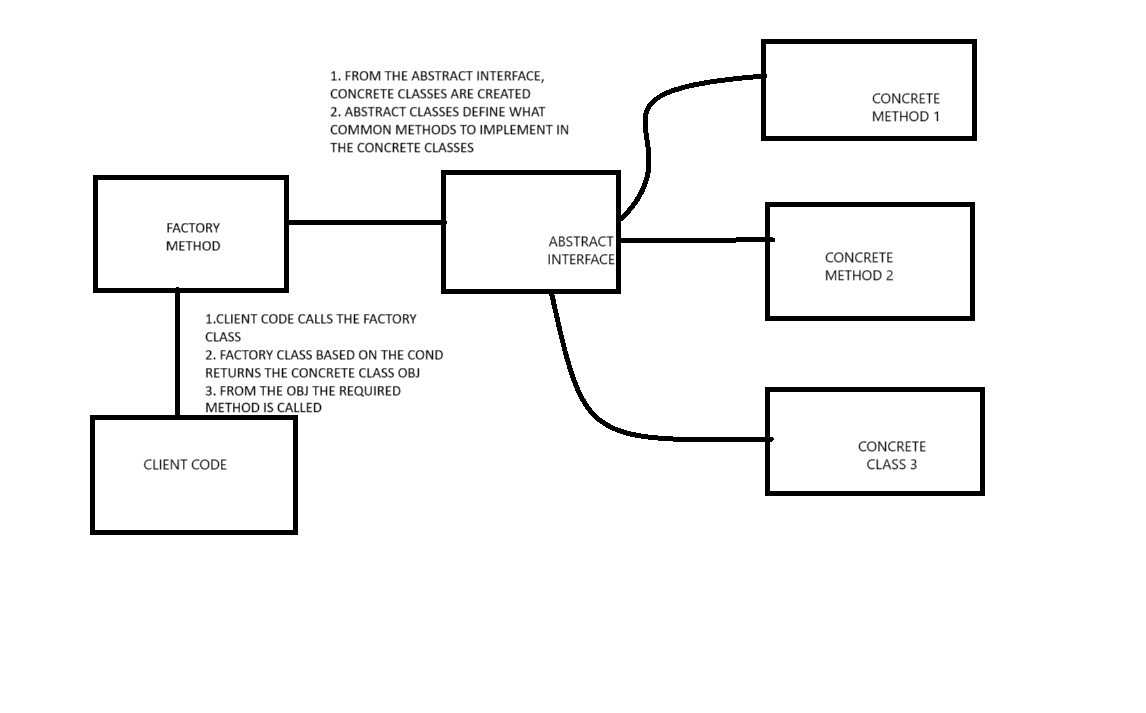

In [ ]:
# Abstract Interface

from abc import abstractmethod,ABC

class CommunicationChannels(ABC):
    @abstractmethod
    def success_msg(self):
        pass

    @abstractmethod
    def failure_msg(self):
        pass


# ConcreteClassImplementations
class Email(CommunicationChannels):
    def success_msg(self):
        return {"status": "Success", "message": "Email sent successfully"}

    def failure_msg(self):
        return {"status": "Failure", "message": "Email failure, kindly resend"}

class PushNotification(CommunicationChannels):
    def success_msg(self):
        return {"status": "Success", "message": "User successfully notified"}

    def failure_msg(self):
        return {"status": "Failure", "message": "User msgs are queued, kindly check"}

class SMS(CommunicationChannels):
    def success_msg(self):
        return {"status": "Success", "message": "Your order has been shipped!"}

    def failure_msg(self):
        return {"status": "Failure", "message": "Delivery Failure"}
    

# Factory Class
class NotificationFactory:
    def get_notification(self,notify_type):
        notification_classes = {
            "email":Email(),
            "push":PushNotification(),
            "sms":SMS()
        }

        return notification_classes.get(notify_type.lower())
    
# Constants for Status Codes
SUCCESS = 200
FAILURE = 400
    
# Client Code
if __name__ == "__main__":
    notify_type,status_code = input("Enter the notification type (email/push/sms) and status code(200,400): ").split()
    
    factory = NotificationFactory()
    notification_channel = factory.get_notification(notify_type)

    if notification_channel is None:
        print("Error: Enter a valid notification type!")
        exit()

    if int(status_code) == SUCCESS:
        print(notification_channel.success_msg())
    elif int(status_code) == FAILURE:
        print(notification_channel.failure_msg())
    else:
        print("Invalid Status Code!")




{'status': 'SMS Notification Sent', 'message': 'Your order has been shipped!'}


### Abstract Factory Pattern

- You are building a Food Delivery System that supports different cuisines (Italian, Indian, and Chinese). Each cuisine has:
    - A Main Course (e.g., Pasta, Biryani, Noodles)
    - A Beverage (e.g., Wine, Lassi, Green Tea)
- Implement the Abstract Factory Pattern to allow users to dynamically request a meal based on cuisine type.
- Expose this as an API where users can request their preferred cuisine.


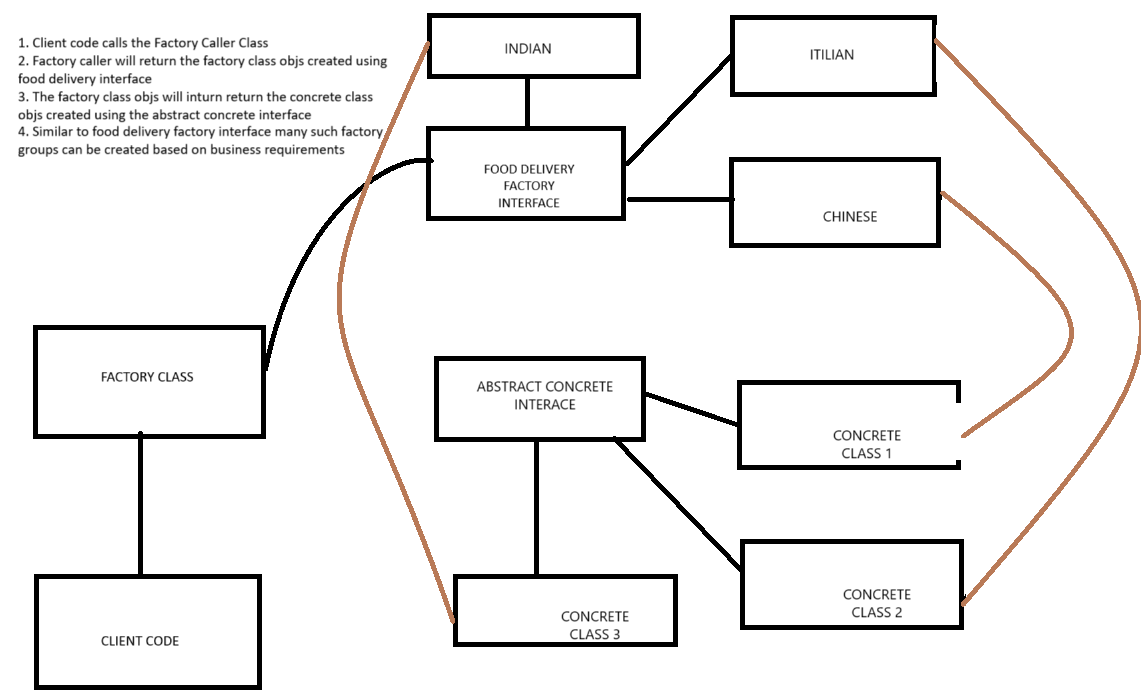

In [24]:
from abc import abstractmethod,ABC

#Concrete Interface
class CuisineAbstractInterface(ABC):
    @abstractmethod
    def meal(self):
        pass

#Concrete Class Implementation
class IndianCuisine(CuisineAbstractInterface):
    def meal(self):
        return {
            "main_course":"Biryani",
            "beverage":"Lassi"
        }
    
class ItalianCuisine(CuisineAbstractInterface):
    def meal(self):
        return {
            "main_course":"Pasta",
            "Beverage":"Wine"
        }
    
class ChiniseCuisine(CuisineAbstractInterface):
    def meal(self):
        return {
            "main_course":"Noodles",
            "beverage":"Green Tea"
        }
    
#Factory Interface
class FoodDeliveryFactoryInterface(ABC):
    @abstractmethod
    def order_meal(self):
        pass

#Factory Class Implementation
class IndianFood(FoodDeliveryFactoryInterface):
    def order_meal(self):
        return IndianCuisine().meal()
    
class ItalianFood(FoodDeliveryFactoryInterface):
    def order_meal(self):
        return ItalianCuisine().meal()
    
class ChiniseFood(FoodDeliveryFactoryInterface):
    def order_meal(self):
        return ChiniseCuisine().meal()
    
#Factory Handler Class
class FactoryCallingFunction:
    def get_menu(self,cuisine):
        cuisine_classes = {
            "indian":IndianFood(),
            "italian":ItalianFood(),
            "chinise":ChiniseFood()
        }

        factory_instance = cuisine_classes.get(cuisine.lower())
        return factory_instance.order_meal() if factory_instance else None

#ClientCode
if __name__ == "__main__":
    cuisine_type = input("Enter your cuisinse (Indian/Chinise/Italian) ")
    abstract_factory = FactoryCallingFunction()
    available_food_items = abstract_factory.get_menu(cuisine_type)
    if available_food_items is None:
        print('Kindly enter a valid type')

    else:
        print('The available food items are : ')
        print()
        print(available_food_items)


The available food items are : 

{'main_course': 'Noodles', 'beverage': 'Green Tea'}


### Builder Pattern

- You are designing a Laptop Configurator for a tech store where users can customize their laptop before purchasing. The laptop has:
    - Processor (Intel i5, i7, Ryzen 5, etc.)
    - RAM (8GB, 16GB, 32GB)
    - Storage (SSD, HDD)
    - Graphics Card (Optional)
- Implement the Builder Pattern so that users can select only the features they need.
- Expose an API where users can send a JSON request to configure a laptop.